# Assignment-10: Wholesale Customers Clustering
### Setup & Data Loading

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# Load dataset
df = pd.read_csv('./Wholesale_customers_data.csv')
print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (440, 8)


,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


### Exploratory Data Analysis (EDA)

Channel             0
Region              0
Fresh               0
Milk                0
Grocery             0
Frozen              0
Detergents_Paper    0
Delicassen          0
dtype: int64


,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
count,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000
mean,1.322727,2.543182,12000.297727,5796.265909,7951.277273,3071.931818,2881.493182,1524.870455
std,0.468052,0.774272,12647.328865,7380.377175,9503.162829,4854.673333,4767.854448,2820.105937
min,1.000000,1.000000,3.000000,55.000000,3.000000,25.000000,3.000000,3.000000
25%,1.000000,2.000000,3127.750000,1533.000000,2153.000000,742.250000,256.750000,408.250000
50%,1.000000,3.000000,8504.000000,3627.000000,4755.500000,1526.000000,816.500000,965.500000
75%,2.000000,3.000000,16933.750000,7190.250000,10655.750000,3554.250000,3922.000000,1820.250000
max,2.000000,3.000000,112151.000000,73498.000000,92780.000000,60869.000000,40827.000000,47943.000000


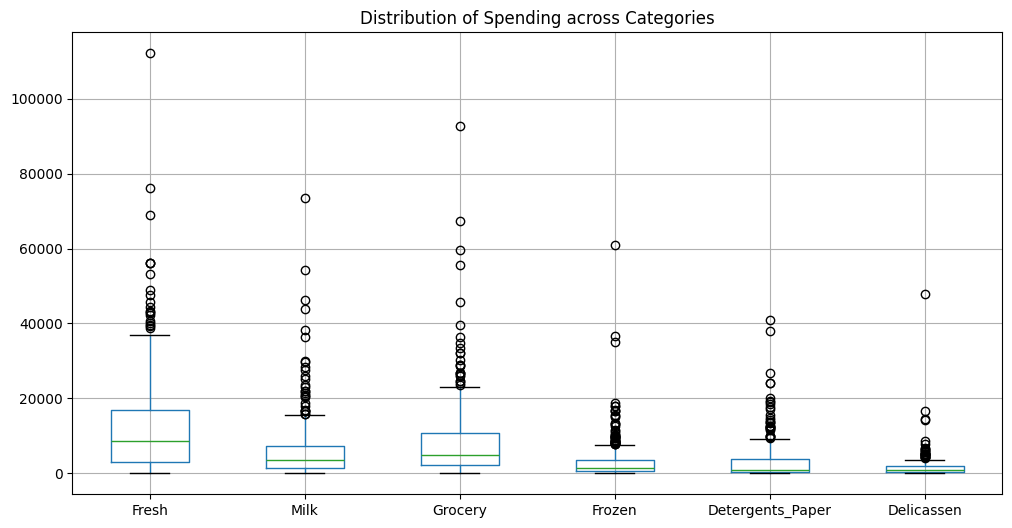

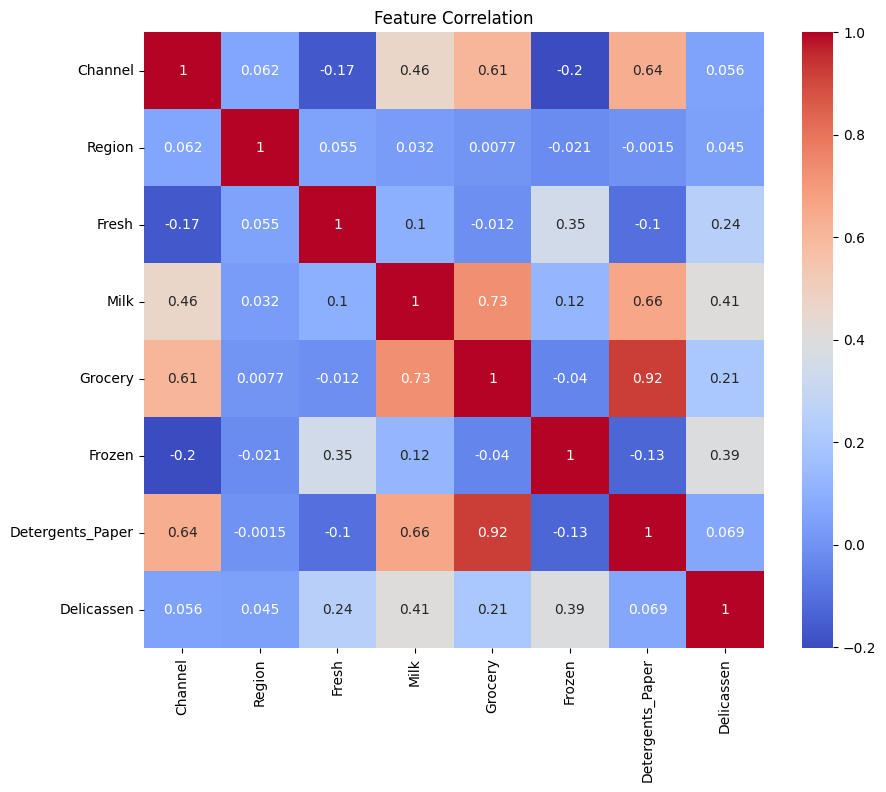

In [3]:
# Check for missing values
print(df.isnull().sum())

# Summary Statistics
display(df.describe())

# Visualizing Distributions
plt.figure(figsize=(12, 6))
df.drop(['Channel', 'Region'], axis=1).boxplot()
plt.title("Distribution of Spending across Categories")
plt.show()

# Correlation Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation")
plt.show()

### Preprocessing
Scaling is essential for clustering as it is distance-based. We will also drop 'Channel' and 'Region' to focus on spending behavior.

In [4]:
# Dropping categorical features for clustering
data_cluster = df.drop(['Channel', 'Region'], axis=1)

# Log transformation to handle skewness
data_log = np.log(data_cluster + 1)

# Scaling
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_log)

### K-Means Clustering & Evaluation

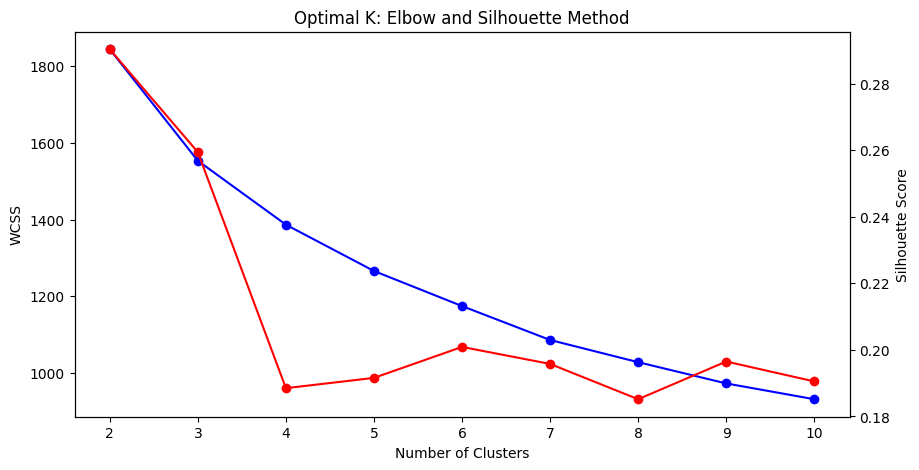

In [5]:
# Elbow Method
wcss = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(data_scaled)
    wcss.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(data_scaled, kmeans.labels_))

# Plotting Elbow and Silhouette
fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(K_range, wcss, 'bo-', label='WCSS (Elbow)')
ax1.set_xlabel('Number of Clusters')
ax1.set_ylabel('WCSS')

ax2 = ax1.twinx()
ax2.plot(K_range, silhouette_scores, 'ro-', label='Silhouette Score')
ax2.set_ylabel('Silhouette Score')

plt.title('Optimal K: Elbow and Silhouette Method')
plt.show()

### Final Model & Cluster Profiling
Based on the analysis, K=3 provides a balanced segmentation.

Average spending per cluster:


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
Cluster,,,,,,
0,2898.575000,7135.937500,12569.712500,606.550000,5554.387500,782.862500
1,17042.836735,10559.666667,13333.598639,4133.095238,4987.020408,2846.591837
2,11938.723005,2005.685446,2502.093897,3265.544601,424.478873,891.384977


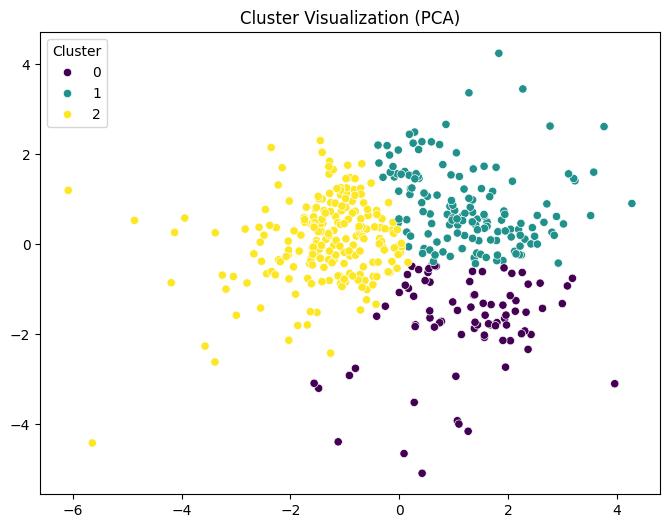

In [6]:
# Fitting K-Means with K=3
kmeans_final = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Cluster'] = kmeans_final.fit_predict(data_scaled)

# Profiling Clusters
cluster_profile = df.groupby('Cluster').mean().drop(['Channel', 'Region'], axis=1)
print("Average spending per cluster:")
display(cluster_profile)

# Visualization using PCA
pca = PCA(n_components=2)
pca_data = pca.fit_transform(data_scaled)
plt.figure(figsize=(8, 6))
sns.scatterplot(x=pca_data[:,0], y=pca_data[:,1], hue=df['Cluster'], palette='viridis')
plt.title("Cluster Visualization (PCA)")
plt.show()